# Python club - week 3

This is the third of our python club problems. The aim of these tasks is to allow CCC colleagues to put their python skills to the test. We will hold a dedicated session for each problem to run through solutions and talk through difficulties that people may have encountered.

#### Task

Write a workflow which does the following:

- Creates a function to generate a *half-hourly* solar generation profile for a day, using a gaussian distribution
    * Using the following equation:
        $ f(t) = A \, e^{-\frac{(t - \mu)^2}{2\sigma^2}} $
    * Where:
        * $A$ is the maximum daily generation value in kWh,
        * $t$ is time of day in decimal time formatting e.g. 5:30 AM is 5.5, 8:00 PM is 20.0.
        * $\mu$ is the time of day at which maximum generation occurs, again in decimal time e.g. 12.0 for midday,
        * $\sigma$ is the number of daylight hours **divided by 4.5**, again in decimal time 

    * You have flexibility on how you would like the function to accept and return the data.
        * You could write this to work with ```pandas```, returning either a ```pd.Series``` or ```pd.DataFrame``` with a new column.
        * You could equally do all of this within ```numpy```.
        * You could also do this within a loop, running through the time increments iteratively.

- Once you have this function, you should generate a profile, storing it as a variable, and check that it looks reasonable in whatever way you see fit.

- After this, read in the ```electricity_consumption_profile.csv``` data from ```inputs/data```

- Assuming the solar generation curve you have created is for the same system as the electricity consumption data:
    * Calculates the amounts of solar exported to the grid and self-consumed, assuming all generation is consumed unless there is a surplus.
    * Calculates the residual electricity consumption after the the solar power is used.

- Plots your results in a way which shows what you consider to be the relevant variables.

Example solution below, using pandas.

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [146]:
df = pd.DataFrame(index=np.arange(0,24, 0.5))

df.head()

""
0.0
0.5
1.0
1.5
2.0


In [147]:
def make_solar_generation_profile(df : pd.DataFrame,
                                  peak_generation_value = 1.0,
                                  peak_generation_time = 12.0,
                                  daylight_hours = 15):
    
    output_df = df.copy()
    sigma = daylight_hours / 4.5
    time = df.index # assuming the index is formatted in correct way

    output_df["solar_generation_kwh"] = peak_generation_value * np.exp(
        -0.5*((time - peak_generation_time)/sigma)**2)

    return output_df

In [148]:
solar_gen_df = make_solar_generation_profile(df=df)
solar_gen_df.head()

,solar_generation_kwh
0.0,0.001534
0.5,0.002603
1.0,0.004318
1.5,0.007004
2.0,0.011109


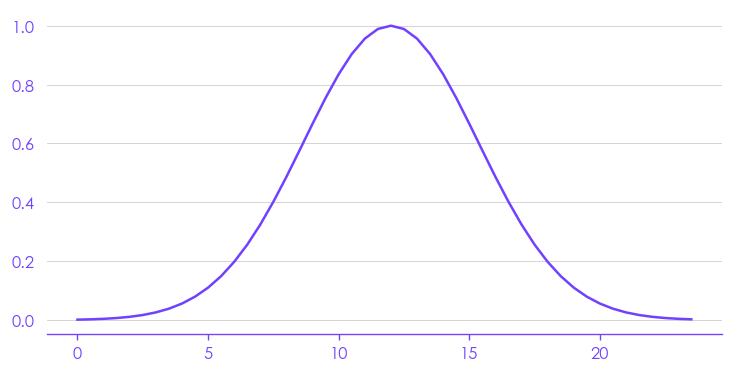

In [149]:
# doing a quick and dirty plot to check this makes sense

plt.plot(solar_gen_df)

In [150]:
# importing the electricity consumption data

elec_consumption_df = pd.read_csv("./data/inputs/electricity_consumption_profile.csv")
elec_consumption_df.head()

,time,household_consumption_kwh
0,00:00,0.135335
1,00:30,0.172422
2,01:00,0.216265
3,01:30,0.267052
4,02:00,0.324653


In [151]:
# let's set the time column as index for this data

elec_consumption_df = elec_consumption_df.set_index("time")

In [152]:
# note - the index looks different here to what we had above - we will need to wrangle it to get it in the same format

solar_gen_df.index = pd.to_datetime(solar_gen_df.index,
                                    unit="h",
                                    origin="2026-01-01" # arbitrary day for formatting purposes
                                    )
solar_gen_df.index = solar_gen_df.index.strftime("%H:%M")
solar_gen_df.head()

,solar_generation_kwh
00:00,0.001534
00:30,0.002603
01:00,0.004318
01:30,0.007004
02:00,0.011109


In [153]:
# now let's join the data

final_df = elec_consumption_df.join(solar_gen_df)

final_df.head()

,household_consumption_kwh,solar_generation_kwh
time,,
00:00,0.135335,0.001534
00:30,0.172422,0.002603
01:00,0.216265,0.004318
01:30,0.267052,0.007004
02:00,0.324653,0.011109


In [154]:
# and now we can calculate the columns for all the additional variables
# starting with solar export (you could do this in any order)

final_df["solar_export_kwh"] = (final_df["solar_generation_kwh"] - final_df["household_consumption_kwh"]
                                ).clip(0)

final_df.head()

,household_consumption_kwh,solar_generation_kwh,solar_export_kwh
time,,,
00:00,0.135335,0.001534,0.0
00:30,0.172422,0.002603,0.0
01:00,0.216265,0.004318,0.0
01:30,0.267052,0.007004,0.0
02:00,0.324653,0.011109,0.0


In [155]:
# now moving on to solar self consumption

final_df["solar_self_consumption_kwh"] = final_df["solar_generation_kwh"] - final_df["solar_export_kwh"]

final_df.head()

,household_consumption_kwh,solar_generation_kwh,solar_export_kwh,solar_self_consumption_kwh
time,,,,
00:00,0.135335,0.001534,0.0,0.001534
00:30,0.172422,0.002603,0.0,0.002603
01:00,0.216265,0.004318,0.0,0.004318
01:30,0.267052,0.007004,0.0,0.007004
02:00,0.324653,0.011109,0.0,0.011109


In [156]:
# and finally residual electricity demand

final_df["residual_electricity_kwh"] = final_df["household_consumption_kwh"] - final_df["solar_self_consumption_kwh"]

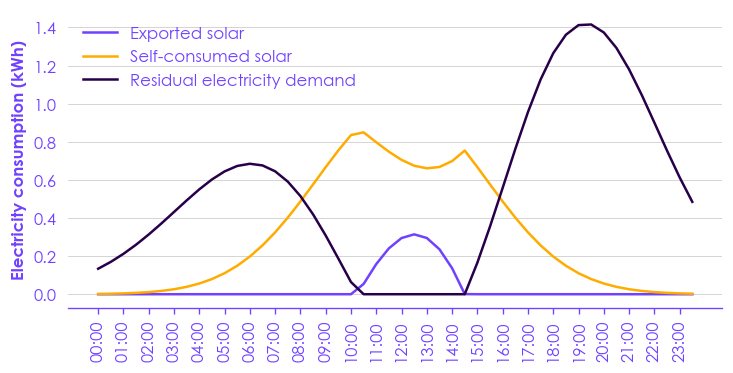

In [157]:
# plotting all of this

import sys
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
sys.path.append(PROJECT_ROOT)

import matplotlib.pyplot as plt
from utils import theme

fig, axs = plt.subplots()

axs.plot(final_df["solar_export_kwh"])
axs.plot(final_df["solar_self_consumption_kwh"])
axs.plot(final_df["residual_electricity_kwh"])

axs.set_ylabel("Electricity consumption (kWh)")
axs.tick_params(axis="x", rotation=90)
axs.set_xticks(axs.get_xticks()[::2])

axs.legend(["Exported solar",
            "Self-consumed solar",
            "Residual electricity demand"])

- Bonus exercise:
    * Read in the ```solar_profile_params.json``` file
    * Use this to create a curve for each month of the year
    * Plot all of those curves together to show how solar generation varies across the year

In [181]:
import json

with open("./data/inputs/solar_profile_params.json", "r", encoding="utf-8") as f:
    parameters_dict = json.load(f)


In [182]:
parameters_dict

{'January': {'peak_generation': 0.5, 'daylight_hours': 7.5},
 'February': {'peak_generation': 0.64, 'daylight_hours': 9.83},
 'March': {'peak_generation': 0.78, 'daylight_hours': 12.2},
 'April': {'peak_generation': 0.9, 'daylight_hours': 14.36},
 'May': {'peak_generation': 0.97, 'daylight_hours': 16.0},
 'June': {'peak_generation': 1.0, 'daylight_hours': 16.89},
 'July': {'peak_generation': 0.97, 'daylight_hours': 16.89},
 'August': {'peak_generation': 0.9, 'daylight_hours': 16.0},
 'September': {'peak_generation': 0.78, 'daylight_hours': 14.36},
 'October': {'peak_generation': 0.64, 'daylight_hours': 12.2},
 'November': {'peak_generation': 0.5, 'daylight_hours': 9.83},
 'December': {'peak_generation': 0.37, 'daylight_hours': 7.5}}

In [185]:
df_list = []

for month in parameters_dict:
    temp_peak_gen =  parameters_dict.get(month)["peak_generation"]
    temp_daylight_hours = parameters_dict.get(month)["daylight_hours"]
    temp_df = make_solar_generation_profile(df=df,
                                            peak_generation_value=temp_peak_gen,
                                            daylight_hours=temp_daylight_hours)
    temp_df.index = pd.to_datetime(temp_df.index,
                                   unit="h",
                                   origin="2000-01-01" 
                                   )
    temp_df.index = temp_df.index.strftime("%H:%M")
    df_list.append(temp_df)

results_dict = {month : df for month, df in zip(parameters_dict.keys(), df_list)}

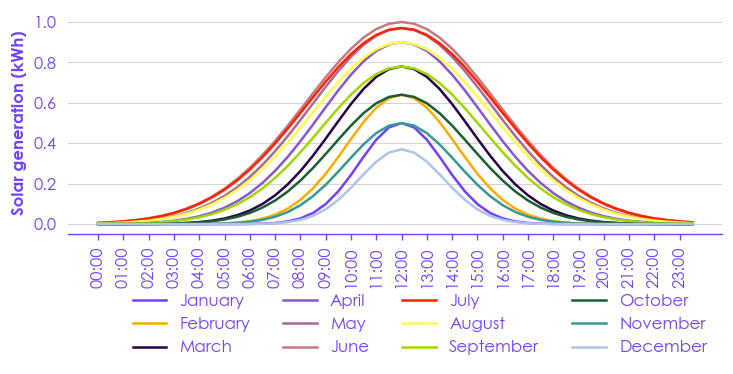

In [188]:
fig, axs = plt.subplots()

for month, df in results_dict.items():
    
    axs.plot(df["solar_generation_kwh"])

axs.set_ylabel("Solar generation (kWh)")
axs.tick_params(axis="x", rotation=90)
axs.set_xticks(axs.get_xticks()[::2])
axs.legend(results_dict.keys(),
           bbox_to_anchor=(1,-0.2),
           ncol=4)